In [32]:
#importing libraries 
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import  KFold
from sklearn.base import BaseEstimator, RegressorMixin
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.model_selection import cross_val_predict

import warnings
warnings.filterwarnings('ignore')

In [33]:
#import dataset
data = pd.read_csv('/home/ramir713/repos/PublicationAnalysis/data/machine_learning_data/data_ready_for_ml')
columns_to_drop = [
 'openalex_id','Unnamed: 0','doi',
    'openalex_url',
    'title',
    'cited_by_count', 'fwci', 'citation_percentile_value',
    'queried_author_raw_name', 'queried_author_raw_affiliation',
    'source_display_name', 'source_issn_l', 'source_issn',
    'source_host_org_name',
    'primary_topic_name',
    'primary_subfield_name',
    'primary_field_name',
    'all_topics', 'sdg_names',
    'sustainable_development_goals',
    'referenced_works', 'related_works','apc_paid_value_usd',
    'sdg_names_list','publication_date','primary_topic_score','citations_year_1_exact', 'citations_year_2_exact',
]
data.drop(columns=columns_to_drop, inplace=True)
data.columns

Index(['publication_year', 'type', 'authors_count', 'countries_distinct_count',
       'institutions_distinct_count', 'corresponding_author_ids',
       'corresponding_institution_ids', 'queried_author_id',
       'queried_author_position', 'queried_author_is_corresponding', 'is_oa',
       'oa_status', 'source_id', 'source_type', 'source_is_oa',
       'apc_list_value_usd', 'primary_topic_id', 'primary_subfield_id',
       'primary_field_id', 'referenced_works_count',
       'citations_first_2y_exact'],
      dtype='str')

In [ ]:
class CatBoostSklearnWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, cat_features=None, iterations=1000, learning_rate=0.05,
                 depth=6, l2_leaf_reg=3, bagging_temperature=1,min_data_in_leaf=1,
                 random_seed=42, thread_count=4, verbose=0):
        
        # Every parameter must be stored with the EXACT same name as the argument
        # This is what makes sklearn's clone() work correctly
        self.cat_features         = cat_features
        self.iterations           = iterations
        self.learning_rate        = learning_rate
        self.depth                = depth
        self.l2_leaf_reg          = l2_leaf_reg
        self.bagging_temperature  = bagging_temperature
        self.random_seed          = random_seed
        self.thread_count         = thread_count
        self.verbose              = verbose
        self.min_data_in_leaf =    min_data_in_leaf
    def fit(self, X, y):
        
        self.model_ = CatBoostRegressor(
            cat_features        = self.cat_features,
            iterations          = self.iterations,
            learning_rate       = self.learning_rate,
            depth               = self.depth,
            l2_leaf_reg         = self.l2_leaf_reg,
            bagging_temperature = self.bagging_temperature,
            random_seed         = self.random_seed,
            thread_count        = self.thread_count,
            verbose             = self.verbose
            min_data_in_leaf    = self.min_data_in_leaf,
            early_stopping_rounds = 50
        )
        self.model_.fit(X, y)
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def get_feature_importance(self):
        return self.model_.get_feature_importance()

In [35]:
# Move to numeric
numeric_cols = ['authors_count', 'countries_distinct_count', 'institutions_distinct_count',
                'apc_list_value_usd', 'referenced_works_count', 'publication_year']

# Clean categoricals
cat_cols = ['type', 'queried_author_position', 'queried_author_is_corresponding',
            'is_oa', 'oa_status', 'source_type', 'source_is_oa',
            'primary_topic_id', 'primary_subfield_id', 'primary_field_id',
            'source_id', 'corresponding_author_ids', 
            'corresponding_institution_ids', 'queried_author_id']

target = 'citations_first_2y_exact'

In [36]:
X = data[numeric_cols + cat_cols].copy()
y = data[target].copy()
X[cat_cols] = X[cat_cols].astype(str).fillna('missing')

preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_cols),
    ('cat', 'passthrough', cat_cols)
])
cat_feature_indices = list(range(len(numeric_cols), len(numeric_cols) + len(cat_cols)))

In [37]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', CatBoostSklearnWrapper(cat_features=cat_feature_indices))
])

In [38]:
param_distributions = {
    'model__iterations':          randint(300, 1500),
    'model__learning_rate':       uniform(0.01, 0.15),
    'model__depth':               randint(4, 10),
    'model__l2_leaf_reg':         randint(1, 10),
    'model__bagging_temperature': uniform(0, 2),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [39]:
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=1,
    verbose=2,
    random_state=42,
    refit=True
)

In [ ]:
# ── 1. Fit the model ──────────────────────────────────────────────────────────
y_log = np.log1p(y)  # Log-transform the target for better modeling
random_search.fit(X, y_log)

# ── 2. Best Parameters & CV Score ─────────────────────────────────────────────
print("=" * 55)
print("BEST PARAMETERS")
print("=" * 55)
for param, value in random_search.best_params_.items():
    print(f"  {param.replace('model__', ''):<25} {value}")
print(f"\n  Best CV RMSE: {-random_search.best_score_:.4f}")
print("=" * 55)
# ── 3. Get the best pipeline & out-of-fold predictions ────────────────────────
best_pipeline = random_search.best_estimator_

# Out-of-fold predictions (honest evaluation — no leakage)
oof_preds_log = cross_val_predict(best_pipeline, X, y_log, cv=cv)
oof_preds = np.expm1(oof_preds_log)  # inverse of log1p
# ── 4. Compute Metrics ────────────────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(y, oof_preds))
mae  = mean_absolute_error(y, oof_preds)
r2   = r2_score(y, oof_preds)

print("\nOUT-OF-FOLD METRICS (honest estimate of real performance)")
print("=" * 55)
print(f"  RMSE : {rmse:.4f}  (avg prediction error in citation units)")
print(f"  MAE  : {mae:.4f}  (avg absolute error)")
print(f"  R²   : {r2:.4f}  (1.0 = perfect, 0.0 = predicts mean only)")
print("=" * 55)
# ── 5. Feature Importance ─────────────────────────────────────────────────────
feature_names  = numeric_cols + cat_cols
importances    = best_pipeline.named_steps['model'].get_feature_importance()
importance_df  = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df  = importance_df.sort_values('importance', ascending=True)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END model__bagging_temperature=0.749080237694725, model__depth=8, model__iterations=1430, model__l2_leaf_reg=8, model__learning_rate=0.09979877262955549; total time=   8.1s
[CV] END model__bagging_temperature=0.749080237694725, model__depth=8, model__iterations=1430, model__l2_leaf_reg=8, model__learning_rate=0.09979877262955549; total time=   8.1s
[CV] END model__bagging_temperature=0.749080237694725, model__depth=8, model__iterations=1430, model__l2_leaf_reg=8, model__learning_rate=0.09979877262955549; total time=   8.1s
[CV] END model__bagging_temperature=0.749080237694725, model__depth=8, model__iterations=1430, model__l2_leaf_reg=8, model__learning_rate=0.09979877262955549; total time=   8.0s
[CV] END model__bagging_temperature=0.749080237694725, model__depth=8, model__iterations=1430, model__l2_leaf_reg=8, model__learning_rate=0.09979877262955549; total time=   8.1s
[CV] END model__bagging_temperature=0.3120372808

Text(0.05, 0.92, 'R² = 0.268\nRMSE = 32.363\nMAE = 13.434')

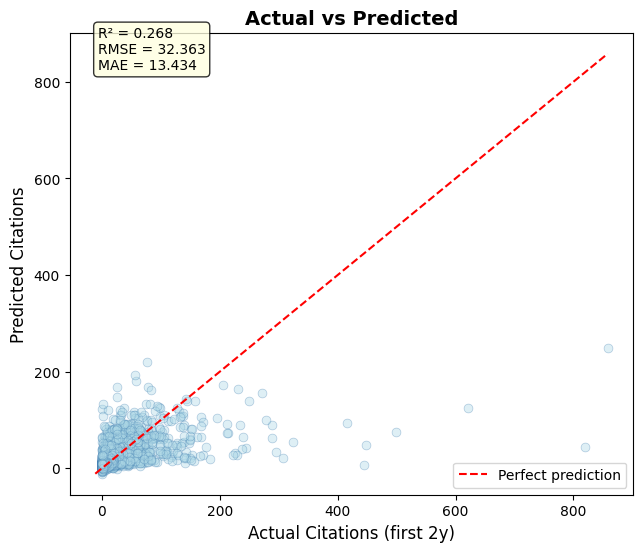

In [41]:
# ── 6. Plots ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig)

# — Plot 1: Actual vs Predicted —
ax1 = fig.add_subplot(gs[0])
ax1.scatter(y, oof_preds, alpha=0.4, edgecolors='steelblue',
            facecolors='lightblue', linewidths=0.5, s=40)

# Perfect prediction line
lims = [min(y.min(), oof_preds.min()), max(y.max(), oof_preds.max())]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')

ax1.set_xlabel('Actual Citations (first 2y)', fontsize=12)
ax1.set_ylabel('Predicted Citations', fontsize=12)
ax1.set_title('Actual vs Predicted', fontsize=14, fontweight='bold')
ax1.legend()
ax1.text(0.05, 0.92, f'R² = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}',
         transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

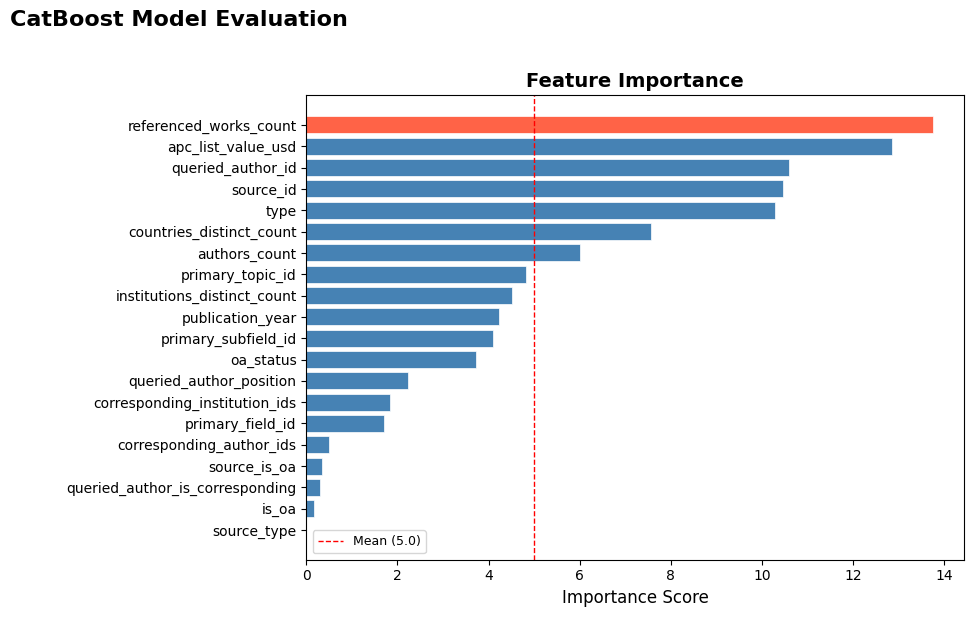

In [43]:

fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig)
# — Plot 2: Feature Importance —
ax2 = fig.add_subplot(gs[1])
colors = ['tomato' if imp == importances.max() else 'steelblue' for imp in importance_df['importance']]
bars = ax2.barh(importance_df['feature'], importance_df['importance'],
                color=colors, edgecolor='white', linewidth=0.5)

ax2.set_xlabel('Importance Score', fontsize=12)
ax2.set_title('Feature Importance', fontsize=14, fontweight='bold')
ax2.axvline(x=importances.mean(), color='red', linestyle='--',
            linewidth=1, label=f'Mean ({importances.mean():.1f})')
ax2.legend(fontsize=9)

plt.suptitle('CatBoost Model Evaluation', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('catboost_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()